#Setup

In [2]:
# Install Necessary Packages
!pip install tensorflow

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

In [4]:
# Load dataset from https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

# Path to the zip file in the Colab file
zip_path = "archive.zip"

# If zipfile exists, extract it into a folder
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("GTSRB")
else:
    raise FileNotFoundError("archive.zip not found")

# Load CSV files
train_df = pd.read_csv("GTSRB/Train.csv")
test_df = pd.read_csv("GTSRB/Test.csv")
meta_df = pd.read_csv("GTSRB/Meta.csv")

# Data exploration
print(train_df.head())
print(train_df.info())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId 

#Data Preparation

In [5]:
# Epoch Variables
Epoch_CNN_Amount = 3
Epoch_MobileNet_Amount = 3

In [6]:
print("Number of traffic sign classes:", train_df["ClassId"].nunique())

Number of traffic sign classes: 43


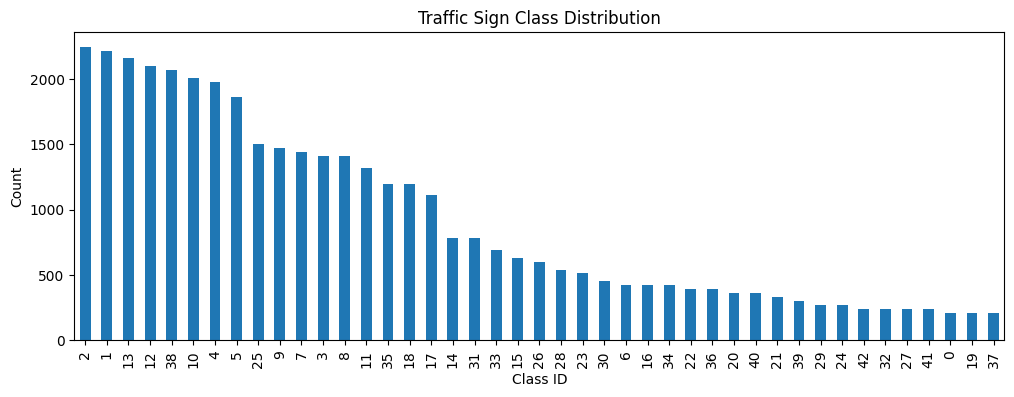

In [7]:
train_df["ClassId"].value_counts().plot(kind="bar", figsize=(12,4))

plt.title("Traffic Sign Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Count")

plt.show()

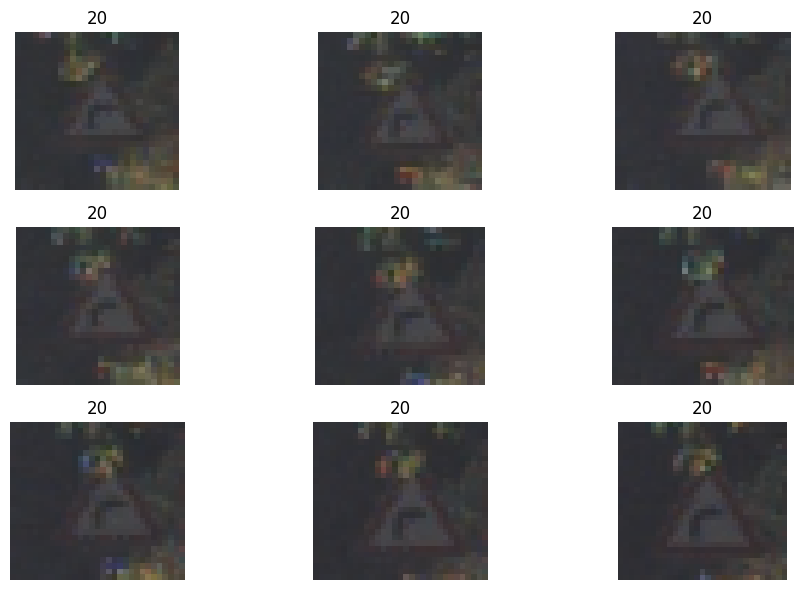

In [8]:
# Plot Images
plt.figure(figsize=(10,6))

for i in range(9):

    img_path = os.path.join("GTSRB", train_df["Path"][i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(train_df["ClassId"][i])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
# Process Images
IMG_SIZE = 32

images = []
labels = []

for i in range(len(train_df)):

    img_path = os.path.join("GTSRB", train_df["Path"][i])

    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    images.append(img)
    labels.append(train_df["ClassId"][i])

x = np.array(images)
y = np.array(labels)

# Normalize pixel values
x = x / 255.0

print("Dataset shape:", x.shape)

Dataset shape: (39209, 32, 32, 3)


In [10]:
# Train and test
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Encode Labels
y_train = to_categorical(y_train, 43)
y_test = to_categorical(y_test, 43)

print("Training set:", x_train.shape)
print("Testing set:", x_test.shape)

Training set: (31367, 32, 32, 3)
Testing set: (7842, 32, 32, 3)


In [11]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)

# CNN Model

In [12]:
# CNN Model
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(43, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Train Model
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=Epoch_CNN_Amount,
    validation_data=(x_test, y_test)
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,523 (923.92 KB)

 Trainable params: 236,075 (922.17 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


491/491 ━━━━━━━━━━━━━━━━━━━━ 79s 155ms/step - accuracy: 0.3900 - loss: 2.3505 - val_accuracy: 0.6549 - val_loss: 1.0155
Epoch 2/3
491/491 ━━━━━━━━━━━━━━━━━━━━ 74s 151ms/step - accuracy: 0.8614 - loss: 0.4303 - val_accuracy: 0.9681 - val_loss: 0.1081
Epoch 3/3
491/491 ━━━━━━━━━━━━━━━━━━━━ 74s 150ms/step - accuracy: 0.9271 - loss: 0.2360 - val_accuracy: 0.9791 - val_loss: 0.0647


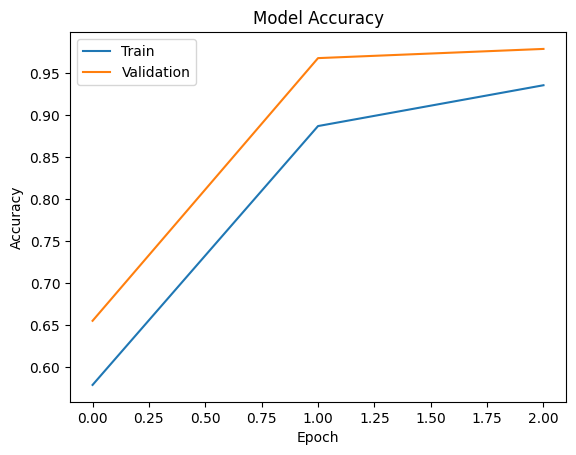

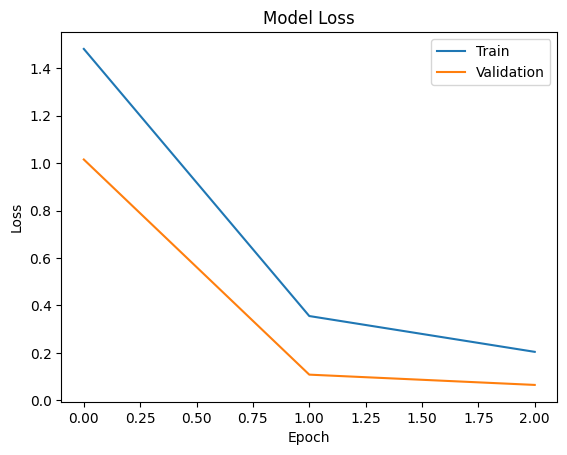

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9802 - loss: 0.0653
Test Accuracy: 97.91 %


In [14]:
# CNN Accuracy Plot
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# CNN Loss Plot
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

# CNN Accuracy
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", round(accuracy*100,2), "%")

246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


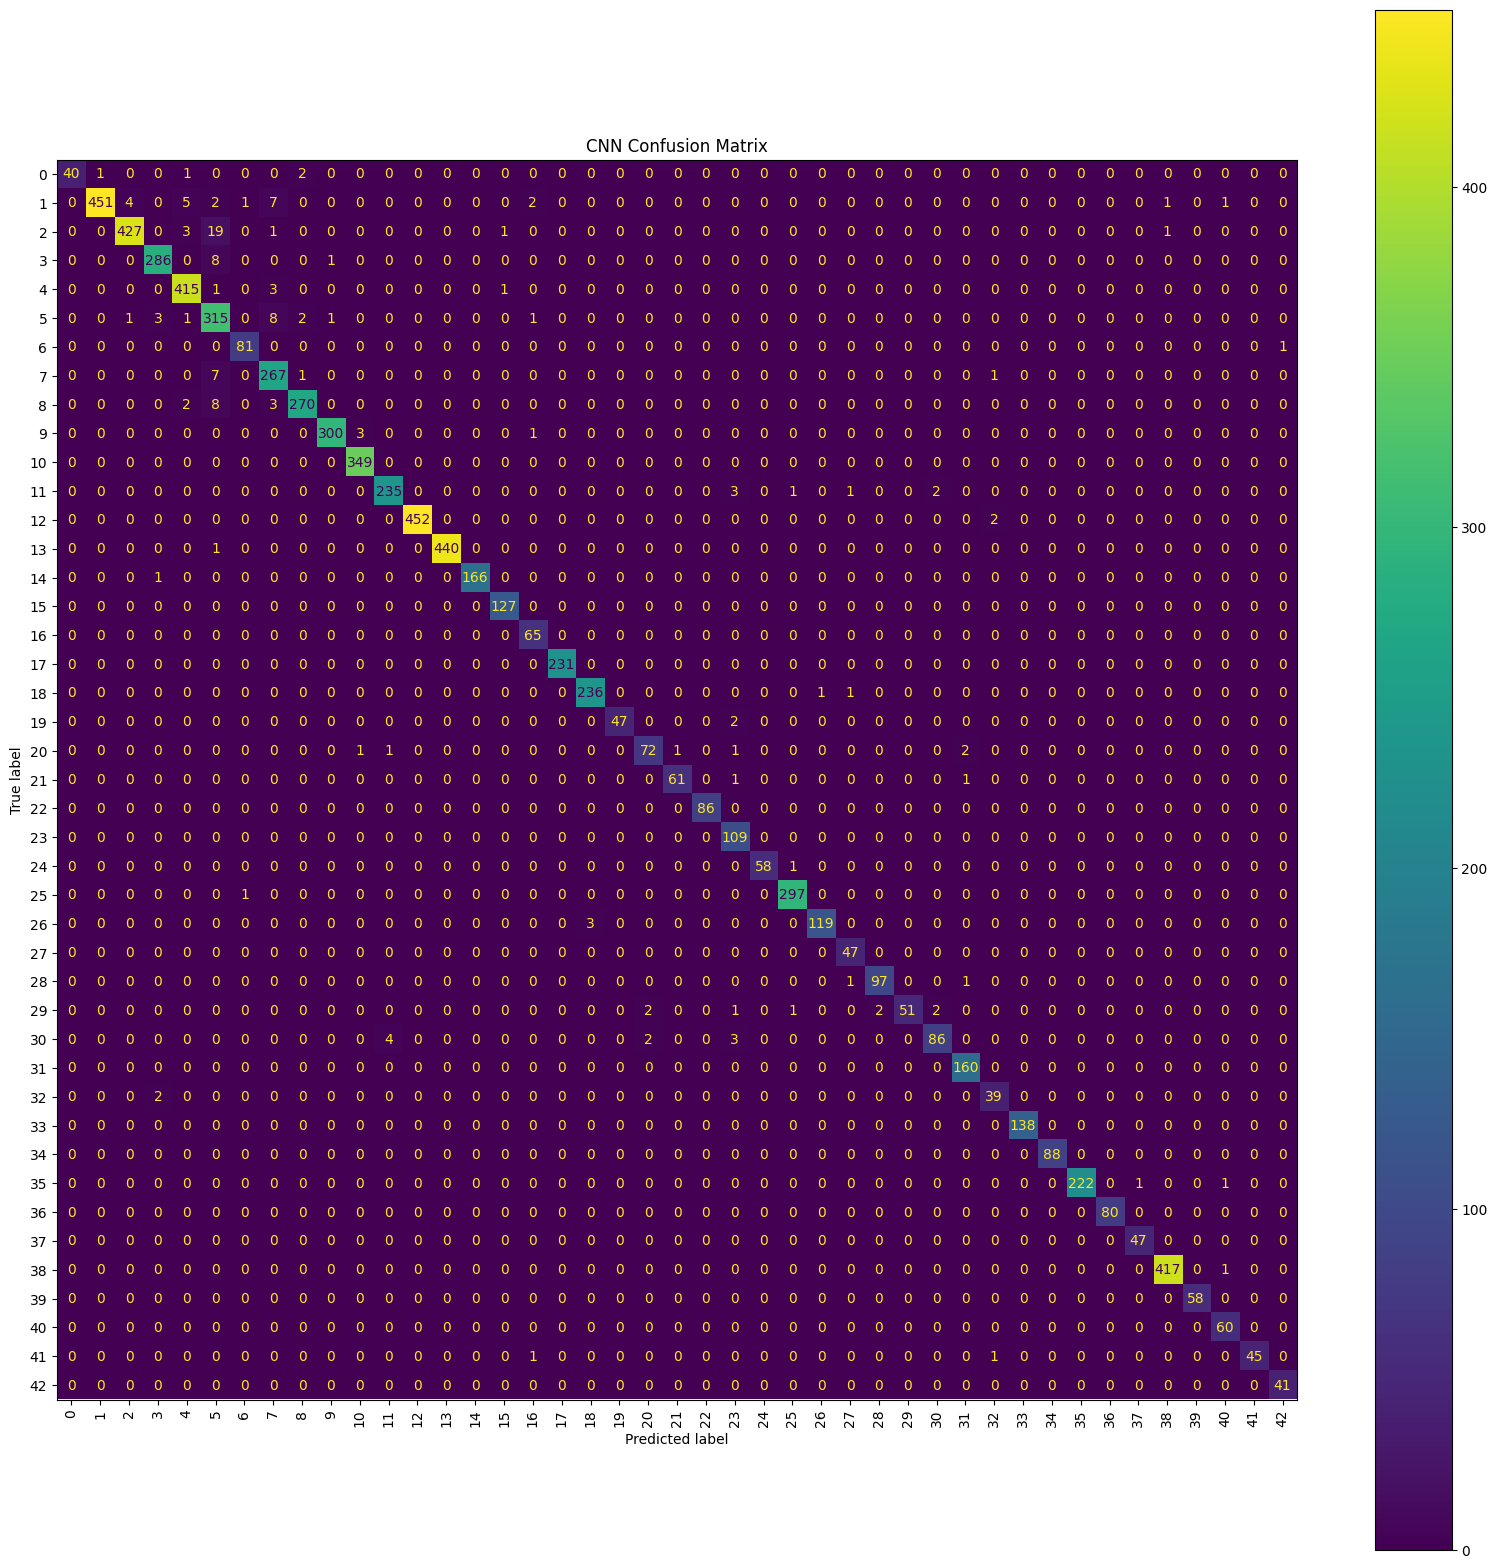

In [27]:
# CNN Confusion Matrix
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(20,20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="viridis", values_format='d', colorbar=True)

plt.xticks(rotation=90)
plt.title("CNN Confusion Matrix")
plt.show()

# MobileNet Model

In [16]:
# MobileNet Transfer Learning Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(32,32,3)
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

mobilenet_model = Sequential()

mobilenet_model.add(base_model)
mobilenet_model.add(Flatten())
mobilenet_model.add(Dense(128, activation="relu"))
mobilenet_model.add(Dropout(0.5))
mobilenet_model.add(Dense(43, activation="softmax"))

mobilenet_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

/tmp/ipykernel_20342/2119199202.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,499 (9.26 MB)

 Trainable params: 169,515 (662.17 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
# Re-encode labels for MobileNet training
y_train = to_categorical(np.argmax(y_train, axis=1), 43)
y_test = to_categorical(y_test, 43)

# Train MobileNet model
mobilenet_history = mobilenet_model.fit(
    x_train,
    y_train,
    batch_size=64,
    epochs=Epoch_MobileNet_Amount,
    validation_data=(x_test, y_test)
)

Epoch 1/3
491/491 ━━━━━━━━━━━━━━━━━━━━ 39s 68ms/step - accuracy: 0.1488 - loss: 3.2171 - val_accuracy: 0.2835 - val_loss: 2.5430
Epoch 2/3
491/491 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.2563 - loss: 2.5719 - val_accuracy: 0.3082 - val_loss: 2.3755
Epoch 3/3
491/491 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.2838 - loss: 2.4428 - val_accuracy: 0.3182 - val_loss: 2.2957


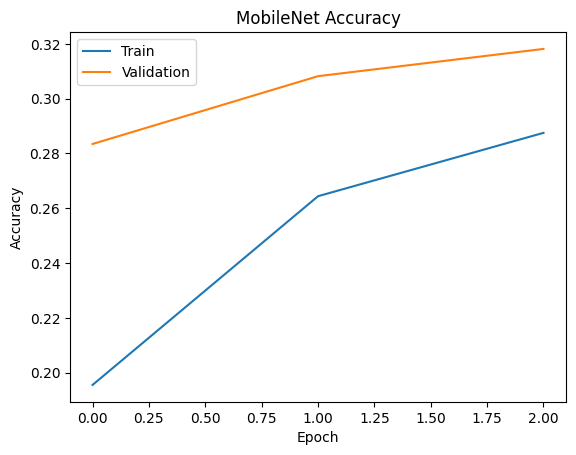

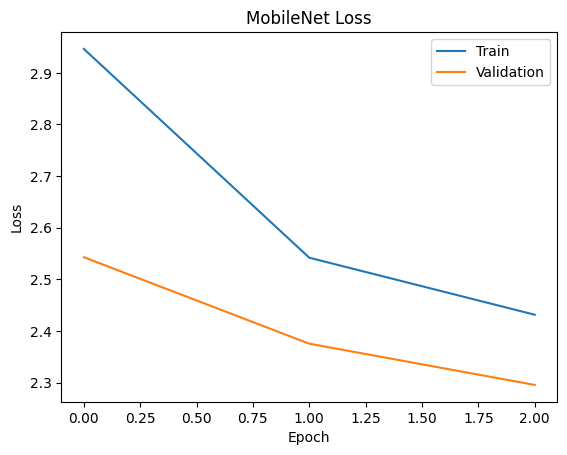

246/246 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.3207 - loss: 2.2832
MobileNet Test Accuracy: 31.82 %


In [18]:
# MobileNet Accuracy Plot
plt.plot(mobilenet_history.history["accuracy"])
plt.plot(mobilenet_history.history["val_accuracy"])

plt.title("MobileNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# MobileNet Loss Plot
plt.plot(mobilenet_history.history["loss"])
plt.plot(mobilenet_history.history["val_loss"])

plt.title("MobileNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

# MobileNet Accuracy
loss_m, accuracy_m = mobilenet_model.evaluate(x_test, y_test)

print("MobileNet Test Accuracy:", round(accuracy_m*100,2), "%")

246/246 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step


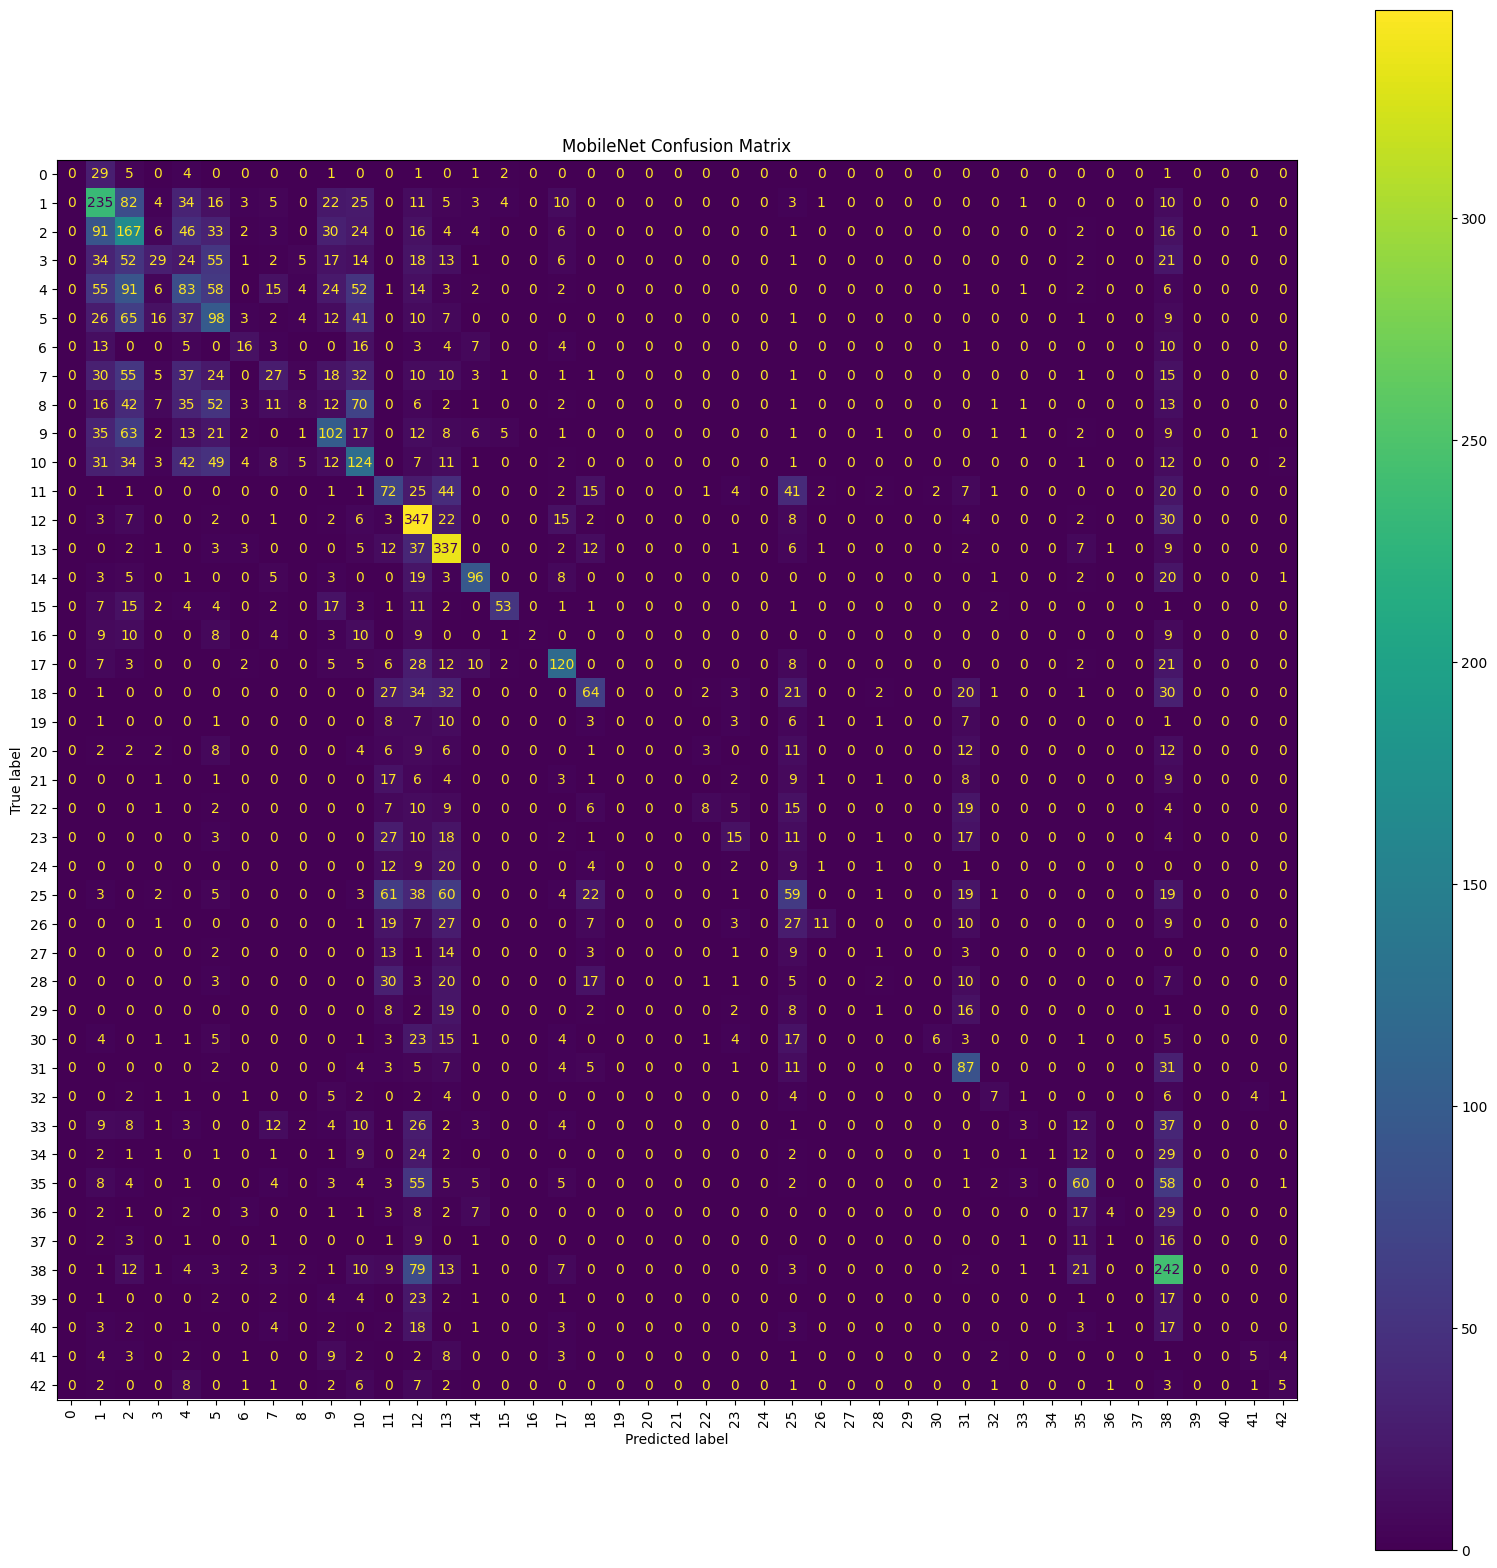

In [34]:
# MobileNet Confusion Matrix

y_pred = mobilenet_model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(20,20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="viridis", values_format='d', colorbar=True)

plt.title("MobileNet Confusion Matrix")
plt.xticks(rotation=90)
plt.show()

# Model Comparison

In [35]:
print("Model Comparison")

print("CNN Accuracy:", round(accuracy*100,2), "%")
print("MobileNet Accuracy:", round(accuracy_m*100,2), "%")

Model Comparison
CNN Accuracy: 97.91 %
MobileNet Accuracy: 31.82 %
